#### IND320 Project Part 1 – Complete Jupyter Notebook


#### Imports and configuration

In [1]:
# ---------------------------------------------------------------------------
# Imports and global plot configuration
# ---------------------------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Nicer default plot style for the whole notebook
plt.rcParams.update({
    "figure.figsize": (12, 4),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
})

# Show all columns when printing data frames
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

#### Load the CSV

In [2]:
# ---------------------------------------------------------------------------
# 1) Read reservoirs.csv with Pandas
# The file is located in D2Dbook/data/reservoirs.csv (relative to notebook).
# ---------------------------------------------------------------------------
csv_path = "reservoirs.csv"
df_raw = pd.read_csv(csv_path)

print(f"Rows: {df_raw.shape[0]:,} | Columns: {df_raw.shape[1]}")
df_raw.head()

Rows: 14,877 | Columns: 11


,dato_Id,omrType,omrnr,iso_aar,iso_uke,fyllingsgrad,kapasitet_TWh,fylling_TWh,neste_Publiseringsdato,fyllingsgrad_forrige_uke,endring_fyllingsgrad
0,1995-09-03,EL,4,1995,35,0.944721,21.079208,19.913979,0001-01-01T00:00:00,0.936888,0.007833
1,2020-11-15,EL,1,2020,46,0.974361,6.003264,5.849344,2020-11-25T13:00:00,0.997406,-0.023046
2,2011-08-28,EL,4,2011,34,0.786499,21.079208,16.578772,0001-01-01T00:00:00,0.787193,-0.000694
3,1998-07-05,EL,3,1998,27,0.793969,8.920932,7.082947,0001-01-01T00:00:00,0.733812,0.060157
4,2011-03-27,EL,4,2011,12,0.300820,21.079208,6.341054,0001-01-01T00:00:00,0.311122,-0.010301




The `reservoirs.csv` dataset contains **14,877 rows and 11 columns**. The dataset includes information about reservoir areas, dates, weeks, filling levels, capacity, filled energy, previous filling levels, and changes in filling levels.

The data was successfully imported using **Pandas**, and the first five rows were displayed to verify that the dataset was loaded correctly. The results show that the dataset contains both numerical and date-related information, which can later be used for analysis and visualization.


####  Rename columns to English

In [3]:
# ---------------------------------------------------------------------------
# 2) Rename columns to English / understandable names
# ---------------------------------------------------------------------------
rename_map = {
    "dato_Id":                  "date",                    # observation date
    "omrType":                  "area_type",               # EL, NO, VASS
    "omrnr":                    "area_nr",                 # numeric area id
    "iso_aar":                  "iso_year",                # ISO year
    "iso_uke":                  "iso_week",                # ISO week
    "fyllingsgrad":             "fill_ratio",              # 0–1 fill level
    "kapasitet_TWh":            "capacity_TWh",            # total capacity
    "fylling_TWh":              "filled_TWh",              # stored energy
    "neste_Publiseringsdato":   "next_publication",        # next publish date
    "fyllingsgrad_forrige_uke": "fill_ratio_prev_week",    # previous week
    "endring_fyllingsgrad":     "fill_ratio_change",       # weekly change
}

df = df_raw.rename(columns=rename_map).copy()

# ---------------------------------------------------------------------------
# Parse the two date columns.
# The placeholder "0001-01-01T00:00:00" (used for already-published rows)
# becomes NaT. We specify `format="mixed"` to silence the UserWarning.
# ---------------------------------------------------------------------------
df["date"] = pd.to_datetime(df["date"], errors="coerce", format="mixed")
df["next_publication"] = pd.to_datetime(
    df["next_publication"], errors="coerce", format="mixed"
)

# A sorted copy is convenient for time-series plotting
df_sorted = df.sort_values("date").reset_index(drop=True)

df.columns.tolist()

['date',
 'area_type',
 'area_nr',
 'iso_year',
 'iso_week',
 'fill_ratio',
 'capacity_TWh',
 'filled_TWh',
 'next_publication',
 'fill_ratio_prev_week',
 'fill_ratio_change']



The column names were renamed from Norwegian to clear and understandable English names to make the dataset easier to work with and interpret. The two date columns were also converted to datetime format. The data was then sorted by date, creating an ordered dataset that is more suitable for time-series analysis and visualization.


#### Print the contents in a relevant way

In [4]:
# ---------------------------------------------------------------------------
# 3) Print the contents in a relevant way
# ---------------------------------------------------------------------------
print("=" * 70)
print("SHAPE")
print("=" * 70)
print(f"Rows: {df.shape[0]:>8,}")
print(f"Cols: {df.shape[1]:>8,}")

print("\n" + "=" * 70)
print("COLUMN DTYPES")
print("=" * 70)
print(df.dtypes)

print("\n" + "=" * 70)
print("CATEGORICAL VALUES")
print("=" * 70)
print("area_type :", sorted(df["area_type"].dropna().unique()))
print("area_nr   :", sorted(df["area_nr"].dropna().unique()))

print("\n" + "=" * 70)
print("DATE RANGE")
print("=" * 70)
print("First observation:", df["date"].min())
print("Last  observation:", df["date"].max())

print("\n" + "=" * 70)
print("MISSING VALUES PER COLUMN")
print("=" * 70)
print(df.isna().sum())

SHAPE
Rows:   14,877
Cols:       11

COLUMN DTYPES
date                    datetime64[ns]
area_type                       object
area_nr                          int64
iso_year                         int64
iso_week                         int64
fill_ratio                     float64
capacity_TWh                   float64
filled_TWh                     float64
next_publication        datetime64[ns]
fill_ratio_prev_week           float64
fill_ratio_change              float64
dtype: object

CATEGORICAL VALUES
area_type : ['EL', 'NO', 'VASS']
area_nr   : [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]

DATE RANGE
First observation: 1995-01-08 00:00:00
Last  observation: 2026-09-06 00:00:00

MISSING VALUES PER COLUMN
date                        0
area_type                   0
area_nr                     0
iso_year                    0
iso_week                    0
fill_ratio                  0
capacity_TWh                0
filled_TWh                  0
next_

The dataset contains **14,877 observations and 11 columns**. The data covers the period from **8 January 1995 to 6 September 2026**. The `area_type` variable contains three categories: **EL, NO, and VASS**, while `area_nr` contains six different area numbers from 0 to 5.

Most columns contain complete data with no missing values. However, `next_publication` contains **11,322 missing values**. This is expected because the value `"0001-01-01T00:00:00"` represents observations that do not have a next publication date. The remaining variables have appropriate numerical, categorical, and datetime data types for further analysis and visualization.

In [5]:
# ---------------------------------------------------------------------------
# First and last rows of the data set
# ---------------------------------------------------------------------------
print("First 5 rows:")
display(df.head())

print("\nLast 5 rows:")
display(df.tail())

First 5 rows:


,date,area_type,area_nr,iso_year,iso_week,fill_ratio,capacity_TWh,filled_TWh,next_publication,fill_ratio_prev_week,fill_ratio_change
0,1995-09-03,EL,4,1995,35,0.944721,21.079208,19.913979,NaT,0.936888,0.007833
1,2020-11-15,EL,1,2020,46,0.974361,6.003264,5.849344,2020-11-25 13:00:00,0.997406,-0.023046
2,2011-08-28,EL,4,2011,34,0.786499,21.079208,16.578772,NaT,0.787193,-0.000694
3,1998-07-05,EL,3,1998,27,0.793969,8.920932,7.082947,NaT,0.733812,0.060157
4,2011-03-27,EL,4,2011,12,0.300820,21.079208,6.341054,NaT,0.311122,-0.010301



Last 5 rows:


,date,area_type,area_nr,iso_year,iso_week,fill_ratio,capacity_TWh,filled_TWh,next_publication,fill_ratio_prev_week,fill_ratio_change
14872,2026-07-19,VASS,3,2026,29,0.796849,28.155403,22.435612,2026-07-29 13:00:00,0.794957,0.001892
14873,2026-09-06,VASS,3,2026,36,0.826252,28.155403,23.263466,2026-09-16 13:00:00,0.827641,-0.001389
14874,2026-08-30,VASS,3,2026,35,0.827718,28.155403,23.304743,2026-09-09 13:00:00,0.829898,-0.002180
14875,2026-09-06,VASS,1,2026,36,0.570397,36.044464,20.559645,2026-09-16 13:00:00,0.567087,0.003310
14876,2026-09-06,VASS,2,2026,36,0.516978,23.237715,12.013381,2026-09-16 13:00:00,0.514423,0.002555


The first and last five rows show that the dataset contains observations from different dates, area types, and area numbers. The first rows include observations from **1995 to 2020**, while the last rows contain observations from **2026**. This confirms that the dataset covers a long time period and includes several reservoir areas.

The `fill_ratio`, `capacity_TWh`, and `filled_TWh` values provide information about reservoir filling levels and stored energy. The `next_publication` column contains `NaT` for some earlier observations, while more recent observations contain actual publication dates.

In [6]:
# ---------------------------------------------------------------------------
# Descriptive statistics for the numeric columns
# ---------------------------------------------------------------------------
df.describe(include=[np.number]).T

,count,mean,std,min,25%,50%,75%,max
area_nr,14877.0,2.333333,1.490762,0.000000,1.000000,2.000000,3.000000,5.000000
iso_year,14877.0,2010.346038,9.146696,1995.000000,2002.000000,2010.000000,2018.000000,2026.000000
iso_week,14877.0,26.405929,15.017910,1.000000,13.000000,26.000000,39.000000,53.000000
fill_ratio,14877.0,0.618852,0.214850,0.055160,0.456234,0.648049,0.802135,1.020072
capacity_TWh,14877.0,29.145860,22.739070,6.003264,17.390587,23.237715,34.043590,87.437580
filled_TWh,14877.0,18.139713,15.966211,0.331142,7.321973,14.501389,22.203530,84.544820
fill_ratio_prev_week,14877.0,0.618890,0.214843,0.055160,0.456356,0.648114,0.802133,1.020037
fill_ratio_change,14877.0,-0.000038,0.031385,-0.242484,-0.022395,-0.007072,0.016277,0.336623



The descriptive statistics provide an overview of the numerical variables in the dataset, including their mean, standard deviation, minimum, maximum, and quartile values. These statistics help identify the typical values and variation in reservoir capacity, filling levels, stored energy, and weekly changes. The results also provide a useful basis for understanding the dataset before creating the visualizations.


In [7]:
# ---------------------------------------------------------------------------
# Distribution of the categorical columns
# ---------------------------------------------------------------------------
print("area_type counts:\n", df["area_type"].value_counts(), "\n")
print("area_nr counts:\n", df["area_nr"].value_counts().sort_index())

area_type counts:
 area_type
EL      8265
VASS    4959
NO      1653
Name: count, dtype: int64 

area_nr counts:
 area_nr
0    1653
1    3306
2    3306
3    3306
4    1653
5    1653
Name: count, dtype: int64


The distribution of the categorical variables shows how the observations are divided between the different reservoir areas. The `area_type` variable contains three categories: **EL, NO, and VASS**. The `area_nr` variable contains six area numbers, ranging from **0 to 5**. The counts help show how the dataset is distributed across the different area types and areas.

#### Plot fill_ratio separately 

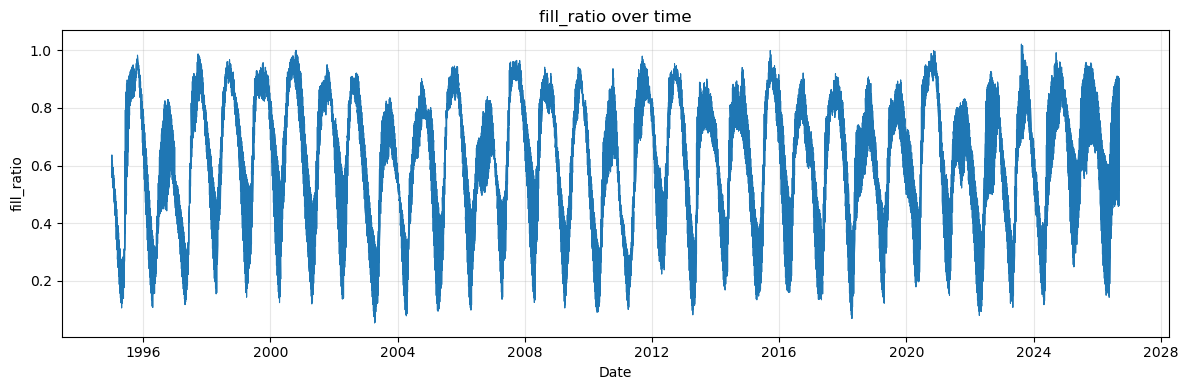

In [8]:
# ---------------------------------------------------------------------------
# 7.1) Plot: fill_ratio over time
# ---------------------------------------------------------------------------
fig, ax = plt.subplots()
ax.plot(df_sorted["date"], df_sorted["fill_ratio"],
        linewidth=0.8, color="tab:blue")
ax.set_title("fill_ratio over time")
ax.set_xlabel("Date")
ax.set_ylabel("fill_ratio")
plt.tight_layout()
plt.show()



The plot shows the development of the reservoir filling ratio over time. The `fill_ratio` variable represents the proportion of reservoir capacity that is filled, with values between 0 and 1. Plotting this variable against the observation date makes it possible to observe changes and variations in reservoir filling levels throughout the dataset's time period.


#### Plot capacity_TWh separately

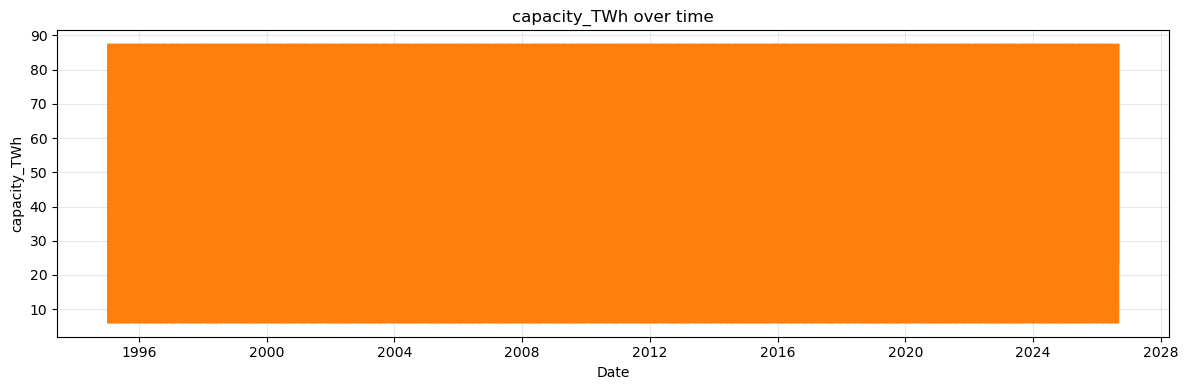

In [9]:
# ---------------------------------------------------------------------------
# 7.2) Plot: capacity_TWh over time
# ---------------------------------------------------------------------------
fig, ax = plt.subplots()
ax.plot(df_sorted["date"], df_sorted["capacity_TWh"],
        linewidth=0.8, color="tab:orange")
ax.set_title("capacity_TWh over time")
ax.set_xlabel("Date")
ax.set_ylabel("capacity_TWh")
plt.tight_layout()
plt.show()



The plot shows how the **reservoir capacity (`capacity_TWh`) changes over time**. The values represent the total reservoir storage capacity in **TWh**. The time-series plot makes it possible to observe long-term changes and variations in reservoir capacity throughout the dataset period.


#### Plot filled_TWh separately

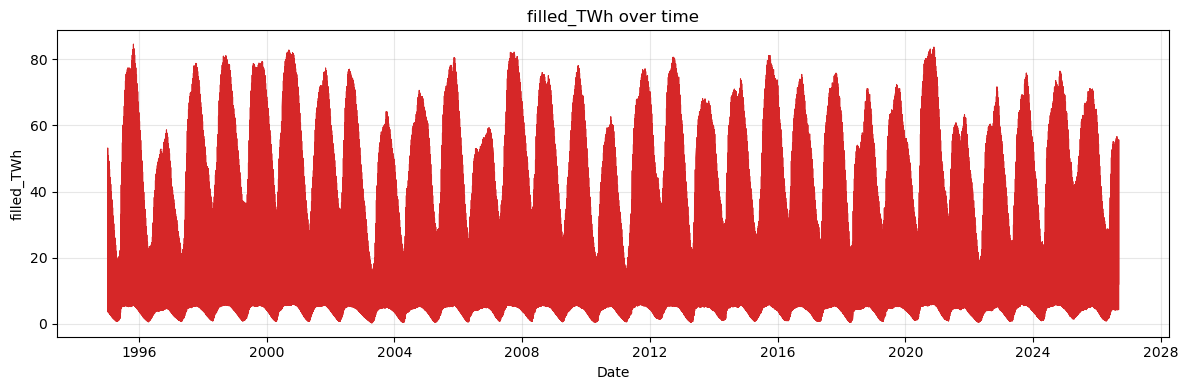

In [10]:
# ---------------------------------------------------------------------------
# 7.3) Plot: filled_TWh over time
# ---------------------------------------------------------------------------
fig, ax = plt.subplots()
ax.plot(df_sorted["date"], df_sorted["filled_TWh"],
        linewidth=0.8, color="tab:red")
ax.set_title("filled_TWh over time")
ax.set_xlabel("Date")
ax.set_ylabel("filled_TWh")
plt.tight_layout()
plt.show()

filled_TWh` is the currently stored energy in each reservoir (or
aggregate). The shape of this curve mirrors `fill_ratio` very closely,
because `filled_TWh = fill_ratio × capacity_TWh` and capacity is
essentially constant per area.

Two observations:

1. **Same seasonal pattern as `fill_ratio`.** High values in late
   summer and autumn, low values in late winter, repeated every year.
2. **Same vertical "spike" artefact.** Since all areas are plotted
   simultaneously, the curve jumps between the TWh levels of the
   different areas. The maximum in the data set is about 84.5 TWh,
   which corresponds to the NO aggregate close to full capacity
   (87.4 TWh).

#### Plot fill_ratio_prev_week separately 

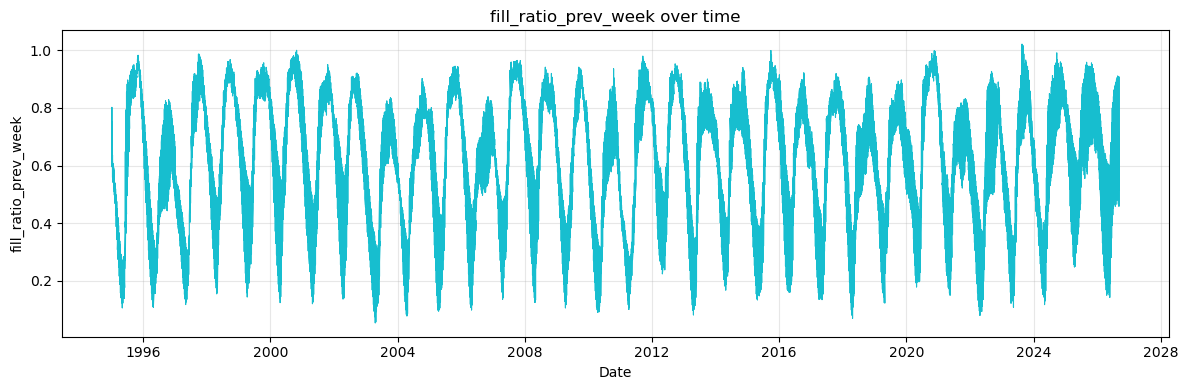

In [11]:
# ---------------------------------------------------------------------------
# 7.4) Plot: fill_ratio_prev_week over time
# ---------------------------------------------------------------------------
fig, ax = plt.subplots()
ax.plot(df_sorted["date"], df_sorted["fill_ratio_prev_week"],
        linewidth=0.8, color="tab:cyan")
ax.set_title("fill_ratio_prev_week over time")
ax.set_xlabel("Date")
ax.set_ylabel("fill_ratio_prev_week")
plt.tight_layout()
plt.show()

The plot shows the **reservoir filling ratio from the previous week (`fill_ratio_prev_week`) over time**. This variable represents the filling level recorded one week earlier, expressed as a ratio of the reservoir capacity. Comparing this historical filling ratio over time helps identify **seasonal patterns, long-term changes, and variations in reservoir levels**.


#### Plot fill_ratio_change separately

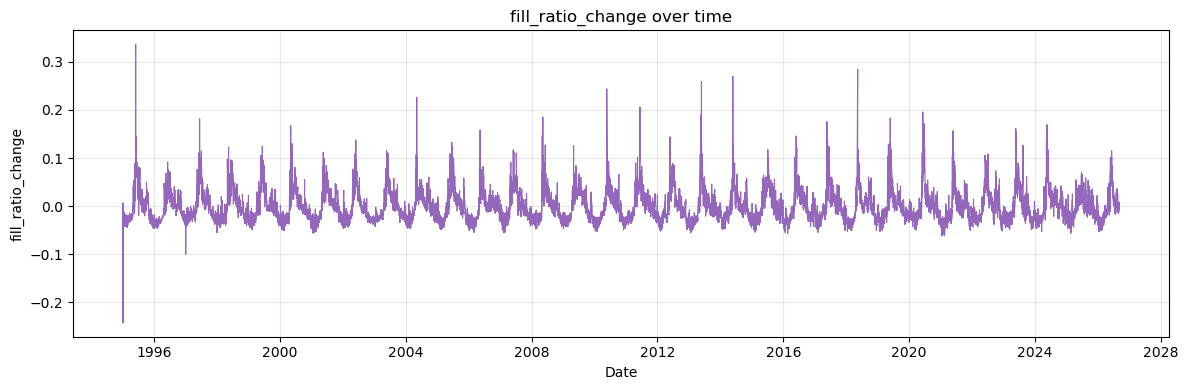

In [12]:
# ---------------------------------------------------------------------------
# 7.5) Plot: fill_ratio_change over time
# ---------------------------------------------------------------------------
fig, ax = plt.subplots()
ax.plot(df_sorted["date"], df_sorted["fill_ratio_change"],
        linewidth=0.8, color="tab:purple")
ax.set_title("fill_ratio_change over time")
ax.set_xlabel("Date")
ax.set_ylabel("fill_ratio_change")
plt.tight_layout()
plt.show()


- In **spring and early summer** the change is positive (snowmelt
  refills reservoirs), often between +0.02 and +0.10 per week.
- In **late autumn and winter** the change is negative (consumption
  exceeds inflow), often between −0.02 and −0.05 per week.
- The whole data set has a **minimum of −0.242** and a **maximum of
  +0.337**. The minimum value (1995-01-08, EL-4) is very likely a data
  correction or an error rather than a physical one-week drop of 24 %
  of capacity. Similarly, the maximum of +0.337 is unusually large.
  Both extremes are worth flagging when the data is used downstream.

The mean is ≈ 0, which is what we would expect for a quantity that
reflects seasonal changes: over a full year, the changes must balance
out.

#### Plot area_type (categorical) 

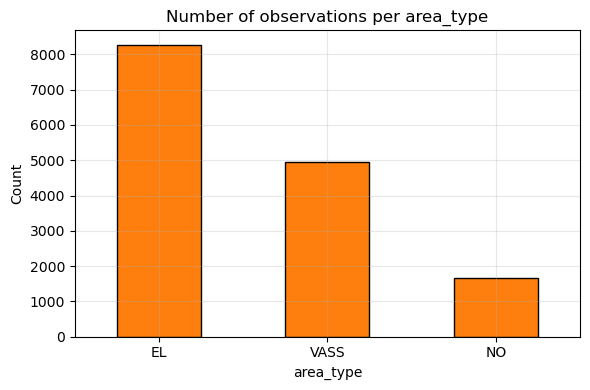

In [13]:
# ---------------------------------------------------------------------------
# 7.6) Plot: area_type (categorical) – value counts
# ---------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(6, 4))
df["area_type"].value_counts().plot(
    kind="bar", ax=ax, color="tab:orange", edgecolor="black"
)
ax.set_title("Number of observations per area_type")
ax.set_xlabel("area_type")
ax.set_ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()




The bar chart shows the **number of observations for each `area_type` category**. The dataset contains three categories: **EL, NO, and VASS**. The chart makes it easy to compare how the observations are distributed between these different area types.


#### Plot area_nr (categorical)

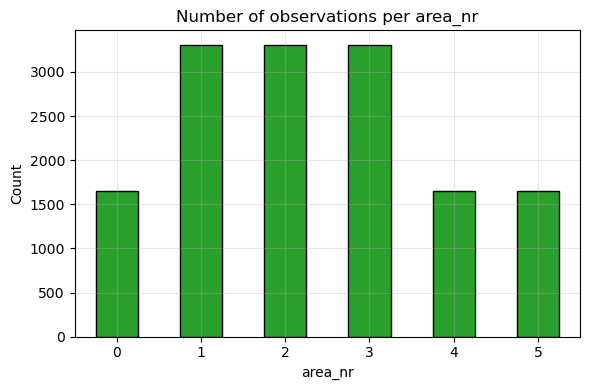

In [14]:
# ---------------------------------------------------------------------------
# 7.7) Plot: area_nr (categorical) – value counts
# ---------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(6, 4))
df["area_nr"].value_counts().sort_index().plot(
    kind="bar", ax=ax, color="tab:green", edgecolor="black"
)
ax.set_title("Number of observations per area_nr")
ax.set_xlabel("area_nr")
ax.set_ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


`area_nr` is a numeric identifier for the area, but it should be treated as a **categorical label rather than a continuous variable**. Plotting the value counts is therefore an appropriate way to summarise its distribution.

The counts show that **areas 1–5** have the largest number of observations, while **area 0** has fewer observations because it represents the national aggregate (`NO`). The `VASS` regions are also included in the area numbering, contributing observations to areas 1–3.

Since `area_type` and `area_nr` are partly related, they should be considered together when analysing individual time series. For example, filtering by both `area_type == "EL"` and `area_nr == 1` gives a more specific and consistent series for further analysis.


####  Plot all numeric columns together (twin axes)

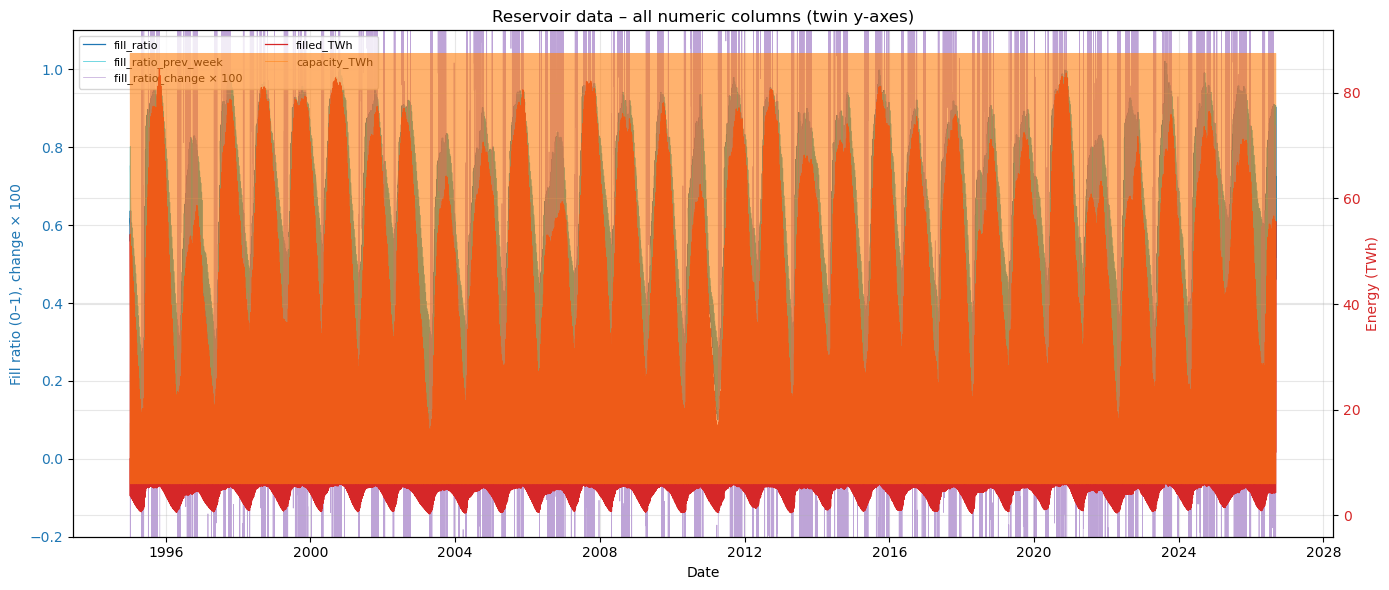

In [15]:
# ---------------------------------------------------------------------------
# 8.1) Plot all numeric columns together – twin y-axes
# ---------------------------------------------------------------------------
# The columns live on very different scales:
#   fill_ratio, fill_ratio_prev_week  ∈ [0, 1]
#   capacity_TWh, filled_TWh          ∈ [0, ~90]
#   fill_ratio_change                 very small (weekly delta)
#
# The natural solution is a twin y-axis:
#   left  axis : fractions (0–1)
#   right axis : TWh values
# The weekly change is multiplied by 100 so that it is visible on the
# left axis.
# ---------------------------------------------------------------------------

fig, ax_left = plt.subplots(figsize=(14, 6))

# --- Left axis: fractions --------------------------------------------------
ax_left.plot(
    df_sorted["date"], df_sorted["fill_ratio"],
    color="tab:blue", linewidth=0.9, label="fill_ratio"
)
ax_left.plot(
    df_sorted["date"], df_sorted["fill_ratio_prev_week"],
    color="tab:cyan", linewidth=0.6, alpha=0.7,
    label="fill_ratio_prev_week"
)
ax_left.plot(
    df_sorted["date"], df_sorted["fill_ratio_change"] * 100,
    color="tab:purple", linewidth=0.5, alpha=0.6,
    label="fill_ratio_change × 100"
)
ax_left.set_xlabel("Date")
ax_left.set_ylabel("Fill ratio (0–1), change × 100", color="tab:blue")
ax_left.tick_params(axis="y", labelcolor="tab:blue")
ax_left.set_ylim(-0.2, 1.1)

# --- Right axis: TWh -------------------------------------------------------
ax_right = ax_left.twinx()
ax_right.plot(
    df_sorted["date"], df_sorted["filled_TWh"],
    color="tab:red", linewidth=0.9, label="filled_TWh"
)
ax_right.plot(
    df_sorted["date"], df_sorted["capacity_TWh"],
    color="tab:orange", linewidth=0.6, alpha=0.6,
    label="capacity_TWh"
)
ax_right.set_ylabel("Energy (TWh)", color="tab:red")
ax_right.tick_params(axis="y", labelcolor="tab:red")

# --- Combined legend -------------------------------------------------------
lines_left, labels_left = ax_left.get_legend_handles_labels()
lines_right, labels_right = ax_right.get_legend_handles_labels()
ax_left.legend(
    lines_left + lines_right,
    labels_left + labels_right,
    loc="upper left", fontsize=8, ncol=2,
)

ax_left.set_title("Reservoir data – all numeric columns (twin y-axes)")
fig.tight_layout()
plt.show()



Plotting all numeric columns together requires careful handling of their different scales. The variables can be divided into **fractions**, **energy values**, and **weekly changes**. A single y-axis would make the fraction variables difficult to see, so a **twin y-axis** is used.

The **left axis** shows the filling ratios, while `fill_ratio_change` is multiplied by 100 to make its smaller variations more visible. The **right axis** shows `filled_TWh` and `capacity_TWh` in TWh.

The plot shows that `fill_ratio` and `filled_TWh` follow similar patterns because they describe related aspects of reservoir filling. `capacity_TWh` represents the available storage capacity, while `fill_ratio_change` shows short-term weekly increases and decreases. Overall, the combined plot provides a useful overview of how the main numerical variables vary over time.


#### Code: Small multiples

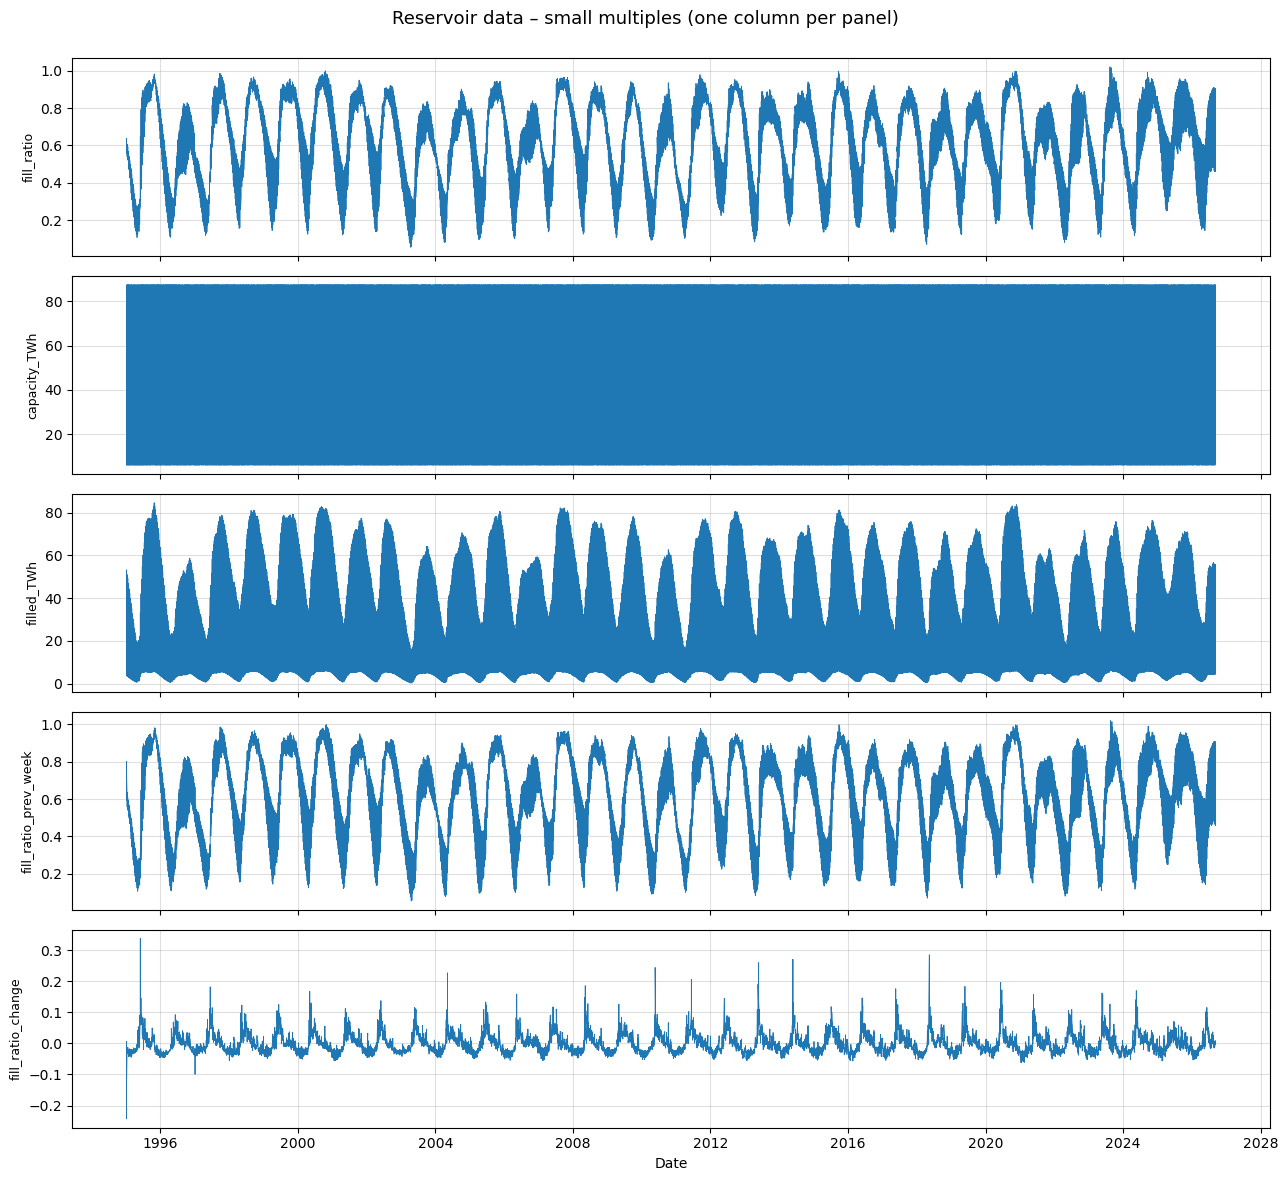

In [16]:
# ---------------------------------------------------------------------------
# 8.2) Alternative view: small-multiples grid (one subplot per column).
# ---------------------------------------------------------------------------
numeric_cols = [
    "fill_ratio",
    "capacity_TWh",
    "filled_TWh",
    "fill_ratio_prev_week",
    "fill_ratio_change",
]

fig, axes = plt.subplots(
    nrows=len(numeric_cols), ncols=1,
    figsize=(13, 2.4 * len(numeric_cols)),
    sharex=True,
)

for ax, col in zip(axes, numeric_cols):
    ax.plot(df_sorted["date"], df_sorted[col],
            linewidth=0.6, color="tab:blue")
    ax.set_ylabel(col, fontsize=9)
    ax.grid(True, alpha=0.4)

axes[-1].set_xlabel("Date")
fig.suptitle("Reservoir data – small multiples (one column per panel)",
             fontsize=13)
fig.tight_layout(rect=(0, 0, 1, 0.98))
plt.show()

The small-multiples figure displays each numeric variable in a separate panel while sharing the same x-axis. This makes it easier to compare the **timing and seasonal patterns** across variables.

The `fill_ratio` and `fill_ratio_prev_week` curves are very similar, reflecting the relationship between the current and previous week's filling levels. The `filled_TWh` variable follows a similar overall pattern because it is directly related to reservoir filling. In contrast, `capacity_TWh` appears as relatively stable levels, while `fill_ratio_change` fluctuates around zero and highlights weekly increases and decreases.

#### Summery
The plots show that the reservoir data has a **strong seasonal pattern**, particularly in `fill_ratio` and `filled_TWh`. However, because the dataset combines different area types and area numbers, some plots contain vertical spikes and variations caused by switching between different regions.

`capacity_TWh` mainly represents the storage capacity of each area and is therefore better used as a **reference value** than as a continuous time series. `fill_ratio_prev_week` closely follows `fill_ratio` because it represents the previous week's filling level, while `fill_ratio_change` captures the weekly increase or decrease in reservoir filling.

The twin-axis plot provides an overview of all numerical variables, but requires careful interpretation because of the different scales. The **small-multiples plot** provides a clearer view of individual variables and makes their seasonal patterns easier to compare.

The analysis suggests that the Streamlit application should allow users to **filter by `area_type` and `area_nr` first**, and then select a variable and time period. This will produce cleaner and more meaningful time-series visualizations than plotting observations from different regions together.

#### PROJECT LOG (300-500 words)



During Part 1 of the IND320 project, I worked with the Norwegian reservoir dataset and developed both a Jupyter Notebook and a Streamlit application. I started by importing the `reservoirs.csv` file using Pandas. The dataset contains 14,877 observations and 11 columns with information about reservoir areas, dates, filling levels, capacity, filled energy, previous filling levels and changes in filling levels.

After importing the data, I renamed the original Norwegian column names to clear and understandable English names. I also converted the date columns to datetime format and sorted the data by date. I inspected the structure of the dataset by checking the number of rows and columns, data types, categorical values, date range and missing values. This helped me understand the dataset before starting the visualization work.

I then created several visualizations. The numerical variables were plotted separately to examine their development over time. I also created bar charts for the categorical variables `area_type` and `area_nr`. The plots showed clear seasonal patterns, especially for `fill_ratio` and `filled_TWh`. I also observed that plotting observations from different areas together can create vertical spikes because the dataset contains several reservoir areas.

To compare the numerical variables together, I created a combined plot using two y-axes because the variables have very different scales. I also created a small-multiples plot where each numerical variable has its own panel. This made it easier to compare the different patterns and seasonal variations.

For the Streamlit part of the project, I developed an interactive web application based on the same reservoir dataset. The application is divided into four pages: a home page, a data table page, a plot page and an about page. The data table displays the imported dataset and uses `LineChartColumn` to visualize the first month of the data series. The plot page allows the user to select a data column and a month range interactively. The application reads the data from a local CSV file and uses Streamlit caching to improve performance.

Working with both the Jupyter Notebook and Streamlit gave me experience with the full process from data loading and exploration to interactive data presentation. The Jupyter Notebook was mainly used for analysis and documentation, while Streamlit was used to make the results accessible through an interactive web application.

####  AI Usage

AI tools were used as a support tool during the IND320 project.
I used AI mainly to help understand programming concepts, troubleshoot
errors, improve the structure of the code, and explain how different
parts of the Jupyter Notebook and Streamlit application work.

For the Jupyter Notebook, AI was used to help with Pandas operations,
data cleaning, date conversion, and Matplotlib visualizations. AI also
helped explain how to visualize variables with different scales and how
to use a twin y-axis and small multiples to make the plots easier to
interpret.

For the Streamlit application, AI was used to help structure the
application into multiple pages and implement features required by the
project. This included loading the CSV data, using `@st.cache_data`,
creating `st.selectbox` and `st.select_slider`, and using
`LineChartColumn` for the first-month visualization. AI was also used
to troubleshoot problems related to running Streamlit, file paths,
Git, GitHub, and deployment.

I also used AI to understand error messages and to improve the
organization and readability of the project. The suggestions were
reviewed and adapted to the actual project requirements and dataset.

The final code was tested locally and the Streamlit application was
deployed online. AI was therefore used as a programming and learning
assistant during development, while I remained responsible for testing
the code, understanding the implementation, and making the final
decisions about the project.

#### Link til Github 
https://github.com/khalidrashed/NMBU-IND320

#### Link til Stramlit
https://nmbu-ind320-hljdkvcappvszzw8hkngnz3.streamlit.app/